In [2]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [3]:
files = ["M13_0001.fits", "M13_0002.fits", "M13_0003.fits", "M13_0004.fits", "M13_0005.fits"]
data_list = []
for file in files:
    with fits.open(file) as hdul:
        data = hdul[0].data
        data_list.append(data)

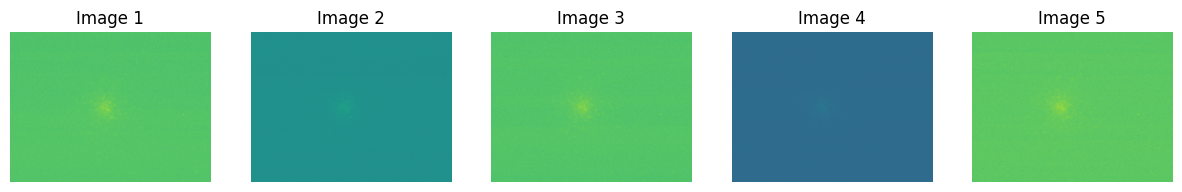

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    axes[i].imshow(data_list[i], origin="lower")
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis("off")

plt.show()

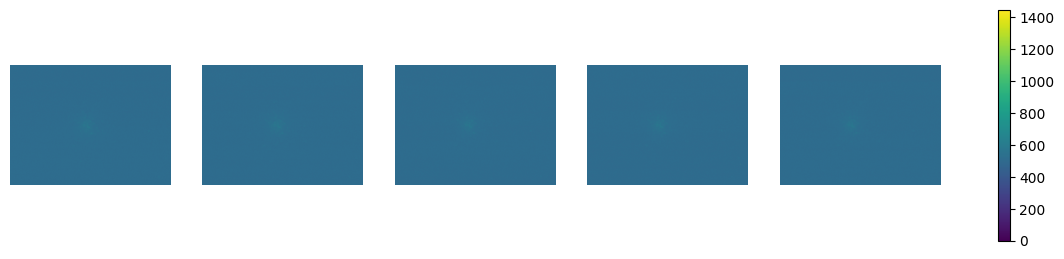

In [5]:
vmin = min(np.min(d) for d in data_list)
vmax = max(np.max(d) for d in data_list)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    im = axes[i].imshow(data_list[i], origin="lower", vmin=vmin, vmax=vmax)
    axes[i].axis("off")

fig.colorbar(im, ax=axes)
plt.show()

In [6]:
# In the first plot, the colors and the shades of green and blue vary. However, in the second one, they are all the same shade of blue.

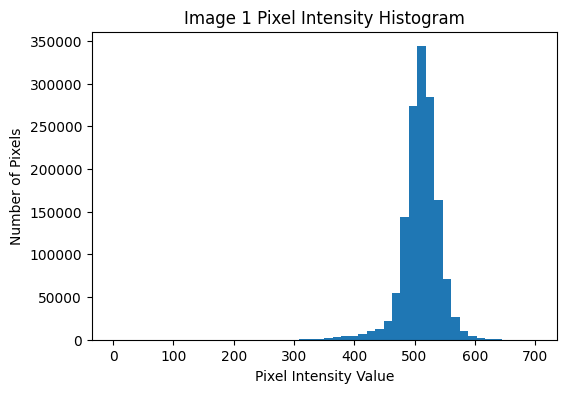

Image 1
Mean: 510.47
Median: 512.00



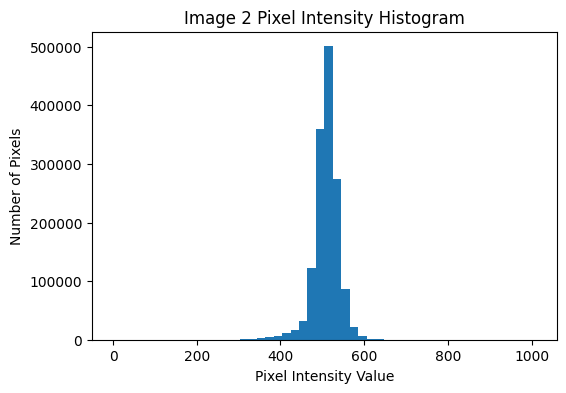

Image 2
Mean: 509.75
Median: 511.00



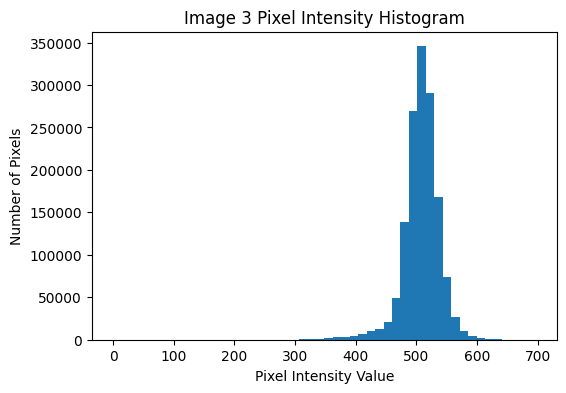

Image 3
Mean: 508.05
Median: 510.00



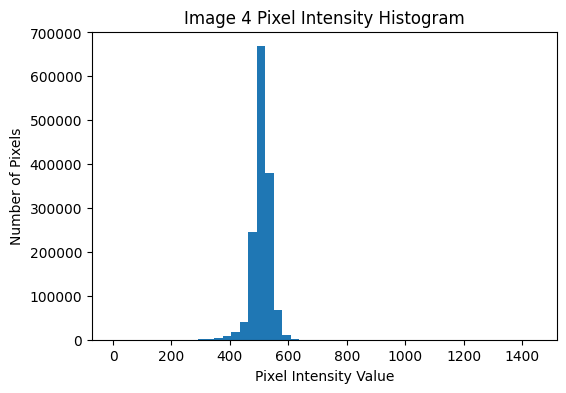

Image 4
Mean: 507.91
Median: 509.00



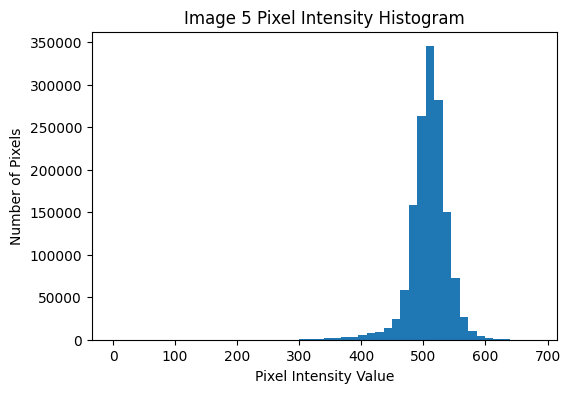

Image 5
Mean: 508.79
Median: 510.00



In [7]:
for i in range(5):
    data = data_list[i]

    plt.figure(figsize=(6, 4))
    plt.hist(data.ravel(), bins=50)
    plt.title(f"Image {i+1} Pixel Intensity Histogram")
    plt.xlabel("Pixel Intensity Value")
    plt.ylabel("Number of Pixels")
    plt.show()

    print(f"Image {i+1}")
    print(f"Mean: {np.mean(data):.2f}")
    print(f"Median: {np.median(data):.2f}")
    print()

In [8]:
# Bins = 50 mean that they group the data points by 50 each bin. 
# Center: all centered around 500
# Spread: pretty closely packed, normal distribution

In [9]:
combined_image = np.median(np.array(data_list), axis=0)
np.median(combined_image)

np.float64(510.0)

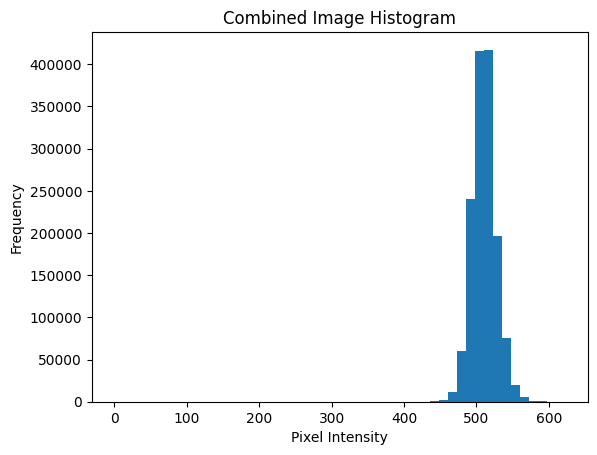

In [10]:
plt.figure()
plt.hist(combined_image.ravel(), bins=50)
plt.title("Combined Image Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

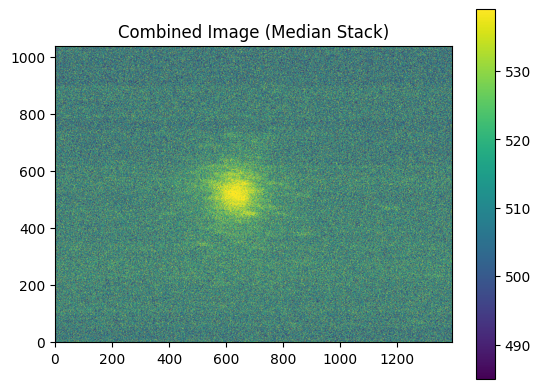

In [11]:
vmin = np.percentile(combined_image, 5)
vmax = np.percentile(combined_image, 95)

plt.imshow(combined_image, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title("Combined Image (Median Stack)")
plt.show()

In [12]:
# The combined image removes noise as compared to the previous ones because you stack the images on top of each other, so the random noise will essentially be less obvious.

In [13]:
fits.writeto("combined.fits", combined_image, overwrite=True)